In [3]:
# Cell 1: Install dependencies and check GPU
!pip install -q albumentations opencv-python-headless

import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

import os, cv2, glob, random, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CUDA available: True
Device: Tesla T4


In [4]:
# Cell 2: Kaggle API authentication
from google.colab import files
print("Upload your kaggle.json file now:")
uploaded = files.upload()  # select kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

Upload your kaggle.json file now:


Saving kaggle.json to kaggle.json


In [5]:
# Cell 3: Download Glaucoma multi-dataset (ORIGA + REFUGE + G1020) by arnavjain1
!kaggle datasets download -d arnavjain1/glaucoma-datasets -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.55G/5.55G [00:55<00:00, 107MB/s]



In [7]:
# Cell 4: Explore what we actually got
!find /content/data -maxdepth 4 -type d | sort
print("\n--- sample file counts per dir ---")
import os
for root, dirs, fnames in os.walk("/content/data"):
    if fnames and root.count(os.sep) <= "/content/data".count(os.sep) + 4:
        print(root, "->", len(fnames), "files | example:", fnames[0])

/content/data
/content/data/G1020
/content/data/G1020/Images
/content/data/G1020/Images_Cropped
/content/data/G1020/Images_Cropped/img
/content/data/G1020/Images_Square
/content/data/G1020/Masks
/content/data/G1020/Masks_Cropped
/content/data/G1020/Masks_Cropped/img
/content/data/G1020/Masks_Square
/content/data/G1020/NerveRemoved_Images
/content/data/models
/content/data/ORIGA
/content/data/ORIGA/Images
/content/data/ORIGA/Images_Cropped
/content/data/ORIGA/Images_Square
/content/data/ORIGA/Masks
/content/data/ORIGA/Masks_Cropped
/content/data/ORIGA/Masks_Square
/content/data/ORIGA/Semi-automatic-annotations
/content/data/REFUGE
/content/data/REFUGE/Images_Square
/content/data/REFUGE/Masks_Square
/content/data/REFUGE/test
/content/data/REFUGE/test/gts
/content/data/REFUGE/test/Images
/content/data/REFUGE/test/Images_Cropped
/content/data/REFUGE/test/Masks
/content/data/REFUGE/test/Masks_Cropped
/content/data/REFUGE/train
/content/data/REFUGE/train/gts
/content/data/REFUGE/train/illust

In [7]:
import os
print(sorted(os.listdir("/content/data/REFUGE/train/Images_Cropped"))[:5])
print(sorted(os.listdir("/content/data/REFUGE/train/Masks_Cropped"))[:5])

['g0001.jpg', 'g0002.jpg', 'g0003.jpg', 'g0004.jpg', 'g0005.jpg']
['g0001.png', 'g0002.png', 'g0003.png', 'g0004.png', 'g0005.png']


Image shape: (346, 346, 3)
Mask shape: (346, 346) dtype: uint8
Unique mask values: [0 1 2]


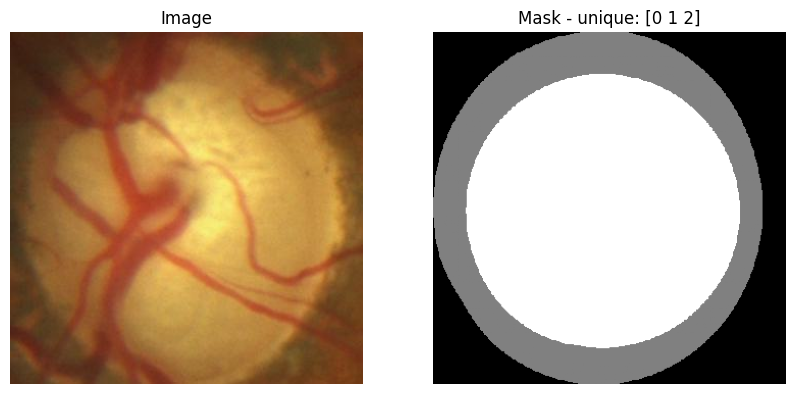

train sample 'g0001.png' unique values: [0 1 2]
val sample 'V0001.png' unique values: [0 1 2]
test sample 'T0001.png' unique values: [0 1 2]


In [8]:
# Cell 5: Inspect how masks are encoded in this specific mirror
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path  = "/content/data/REFUGE/train/Images_Cropped/g0014.jpg"
mask_path = "/content/data/REFUGE/train/Masks_Cropped/g0014.png"  # may need n0197 if g0014 mask missing, adjust filename to match

img  = cv2.imread(img_path)
mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

print("Image shape:", img.shape)
print("Mask shape:", mask.shape, "dtype:", mask.dtype)
print("Unique mask values:", np.unique(mask))

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[0].set_title("Image"); ax[0].axis('off')
ax[1].imshow(mask, cmap='gray'); ax[1].set_title(f"Mask - unique: {np.unique(mask)}"); ax[1].axis('off')
plt.show()

# Also check one from ORIGA/G1020-free, plus val and test split, to confirm consistency
for split in ["train", "val", "test"]:
    folder = f"/content/data/REFUGE/{split}/Masks_Cropped"
    import os
    sample_file = sorted(os.listdir(folder))[0]
    m = cv2.imread(os.path.join(folder, sample_file), cv2.IMREAD_UNCHANGED)
    print(f"{split} sample '{sample_file}' unique values:", np.unique(m))

In [9]:
# Cell 6: Dataset class
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 256  # decided resolution: good accuracy/speed tradeoff on T4 for KAN's spline overhead

class REFUGEDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        # only keep images that actually have a matching mask file
        self.filenames = []
        for f in sorted(os.listdir(img_dir)):
            base = os.path.splitext(f)[0]
            mask_path = os.path.join(mask_dir, base + ".png")
            if os.path.exists(mask_path):
                self.filenames.append((f, base + ".png"))
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name, mask_name = self.filenames[idx]
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)  # values already 0/1/2

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.long()

In [10]:
# Cell 7: Transforms and DataLoaders
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

DATA_ROOT = "/content/data/REFUGE"

train_ds = REFUGEDataset(f"{DATA_ROOT}/train/Images_Cropped", f"{DATA_ROOT}/train/Masks_Cropped", transform=train_transform)
val_ds   = REFUGEDataset(f"{DATA_ROOT}/val/Images_Cropped",   f"{DATA_ROOT}/val/Masks_Cropped",   transform=val_transform)
test_ds  = REFUGEDataset(f"{DATA_ROOT}/test/Images_Cropped",  f"{DATA_ROOT}/test/Masks_Cropped",  transform=val_transform)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Sanity check
imgs, masks = next(iter(train_loader))
print("Batch image shape:", imgs.shape, "Batch mask shape:", masks.shape)
print("Mask unique values in batch:", torch.unique(masks))

Train: 400 Val: 400 Test: 400
Batch image shape: torch.Size([8, 3, 256, 256]) Batch mask shape: torch.Size([8, 256, 256])
Mask unique values in batch: tensor([0, 1, 2])


In [11]:
# Cell 8: KAN Layer built from scratch

class KANLinear(nn.Module):
    """
    Replaces nn.Linear. Instead of one weight per connection, each connection
    is a learnable 1D function: base_activation term (SiLU) + B-spline term.
    """
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3,
                 base_activation=nn.SiLU, grid_range=(-1, 1)):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        # Build the knot vector (grid points), padded on both ends by spline_order
        # so the recursion has enough neighbors at the boundaries.
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]
        grid = grid.expand(in_features, -1).contiguous()  # (in_features, n_knots)
        self.register_buffer("grid", grid)

        # base_weight: the "safety net" linear term (like a normal MLP weight matrix)
        self.base_weight = nn.Parameter(torch.empty(out_features, in_features))
        # spline_weight: coefficients for each B-spline basis function, per connection
        self.spline_weight = nn.Parameter(
            torch.empty(out_features, in_features, grid_size + spline_order)
        )
        self.base_activation = base_activation()

        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5))
        nn.init.normal_(self.spline_weight, mean=0.0, std=0.1)

    def b_splines(self, x):
        """Cox-de Boor recursion: builds B-spline basis values for each input scalar."""
        # x: (batch, in_features)
        grid = self.grid                      # (in_features, n_knots)
        x = x.unsqueeze(-1)                   # (batch, in_features, 1)

        # Order-0 basis: step functions (1 inside the interval, 0 outside)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).float()

        # Recursively blend to build higher-order (smoother) basis functions
        for k in range(1, self.spline_order + 1):
            left  = (x - grid[:, : -(k + 1)]) / (grid[:, k:-1] - grid[:, : -(k + 1)])
            right = (grid[:, k + 1 :] - x) / (grid[:, k + 1 :] - grid[:, 1:-k])
            bases = left * bases[:, :, :-1] + right * bases[:, :, 1:]

        return bases  # (batch, in_features, grid_size + spline_order)

    def forward(self, x):
        orig_shape = x.shape
        x = x.reshape(-1, self.in_features)        # flatten any leading dims (batch, tokens, etc.)

        base_out = F.linear(self.base_activation(x), self.base_weight)   # (batch, out_features)

        spline_basis = self.b_splines(x)            # (batch, in_features, n_basis)
        # einsum: for every output neuron 'o', sum over input 'i' and basis-index 'k'
        spline_out = torch.einsum("bik,oik->bo", spline_basis, self.spline_weight)

        out = base_out + spline_out
        return out.reshape(*orig_shape[:-1], self.out_features)

In [12]:
# Quick sanity test of the KAN layer in isolation
test_layer = KANLinear(in_features=16, out_features=32).to(DEVICE)
test_input = torch.randn(4, 10, 16).to(DEVICE)   # (batch=4, tokens=10, features=16)
test_output = test_layer(test_input)
print("KAN layer test output shape:", test_output.shape)  # expect (4, 10, 32)

KAN layer test output shape: torch.Size([4, 10, 32])


In [13]:
# Cell 9: Tok-KAN Block

class DWConv(nn.Module):
    """Depthwise 3x3 conv applied on token sequences (reshaped back to a 2D grid)."""
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)   # tokens -> feature map
        x = self.dwconv(x)
        x = x.flatten(2).transpose(1, 2)          # feature map -> tokens
        return x


class KANBlock(nn.Module):
    """One Tok-KAN block: LayerNorm -> KAN -> DWConv -> KAN -> residual add."""
    def __init__(self, dim, hidden_dim=None, grid_size=5, spline_order=3, drop=0.0):
        super().__init__()
        hidden_dim = hidden_dim or dim
        self.norm = nn.LayerNorm(dim)
        self.fc1 = KANLinear(dim, hidden_dim, grid_size=grid_size, spline_order=spline_order)
        self.dwconv = DWConv(hidden_dim)
        self.act = nn.GELU()
        self.fc2 = KANLinear(hidden_dim, dim, grid_size=grid_size, spline_order=spline_order)
        self.drop = nn.Dropout(drop)

    def forward(self, x, H, W):
        # x: (B, N, C) tokens
        shortcut = x
        x = self.norm(x)
        x = self.fc1(x)
        x = self.dwconv(x, H, W)
        x = self.act(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x + shortcut

In [14]:
# Sanity test
test_block = KANBlock(dim=32).to(DEVICE)
test_tokens = torch.randn(2, 64, 32).to(DEVICE)  # B=2, N=8x8 tokens, C=32
out = test_block(test_tokens, H=8, W=8)
print("KANBlock output shape:", out.shape)  # expect (2, 64, 32)

KANBlock output shape: torch.Size([2, 64, 32])


In [15]:
# Cell 10: Conv blocks + tokenize/detokenize helpers

class ConvBlock(nn.Module):
    """Standard double conv block: Conv-BN-ReLU x2. Used in the Convolution Phrase."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class PatchEmbed(nn.Module):
    """Feature map -> downsampled tokens. Used entering each Tok-KAN encoder stage."""
    def __init__(self, in_ch, out_ch, stride=2):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1)
        self.norm = nn.LayerNorm(out_ch)

    def forward(self, x):
        x = self.proj(x)                     # (B, out_ch, H/stride, W/stride)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)      # (B, N, C) tokens
        x = self.norm(x)
        return x, H, W


def tokens_to_map(x, H, W):
    """Tokens (B, N, C) -> feature map (B, C, H, W)."""
    B, N, C = x.shape
    return x.transpose(1, 2).reshape(B, C, H, W)


class UpConv(nn.Module):
    """Upsample by 2x (bilinear) + conv to adjust channels. Used in the decoder."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.up(x)
        return self.conv(x)

In [16]:
# Cell 11: Full U-KAN Model (corrected)

class UKAN(nn.Module):
    def __init__(self, num_classes=3, in_ch=3,
                 conv_channels=(64, 128, 256),
                 tok_channels=(320, 512),
                 grid_size=5, spline_order=3):
        super().__init__()
        C1, C2, C3 = conv_channels
        D1, D2 = tok_channels

        # ---- Convolution Phrase (Encoder) ----
        self.conv1 = ConvBlock(in_ch, C1)
        self.conv2 = ConvBlock(C1, C2)
        self.conv3 = ConvBlock(C2, C3)
        self.pool = nn.MaxPool2d(2)

        # ---- Tokenized KAN Phrase (Encoder) ----
        self.patch_embed1 = PatchEmbed(C3, D1, stride=2)
        self.kan_enc1 = KANBlock(D1, grid_size=grid_size, spline_order=spline_order)

        self.patch_embed2 = PatchEmbed(D1, D2, stride=2)
        self.kan_enc2 = KANBlock(D2, grid_size=grid_size, spline_order=spline_order)  # bottleneck

        # ---- Tokenized KAN Phrase (Decoder) ----
        self.up_tok1 = UpConv(D2, D1)          # 8x8  -> 16x16, project D2->D1, matches skip_tok1
        self.kan_dec1 = KANBlock(D1, grid_size=grid_size, spline_order=spline_order)

        self.up_tok2 = UpConv(D1, C3)          # 16x16 -> 32x32, project D1->C3, matches p3
        self.kan_dec2 = KANBlock(C3, grid_size=grid_size, spline_order=spline_order)

        # ---- Convolution Phrase (Decoder) ----
        # upsample keeps channel count == skip's channel count; ConvBlock reduces channels after
        self.up_conv1 = UpConv(C3, C3)          # 32x32 -> 64x64, matches e3 (C3)
        self.dconv1 = ConvBlock(C3, C2)

        self.up_conv2 = UpConv(C2, C2)          # 64x64 -> 128x128, matches e2 (C2)
        self.dconv2 = ConvBlock(C2, C1)

        self.up_conv3 = UpConv(C1, C1)          # 128x128 -> 256x256, matches e1 (C1)
        self.dconv3 = ConvBlock(C1, C1)

        self.head = nn.Conv2d(C1, num_classes, kernel_size=1)

    def forward(self, x):
        # ---------- Encoder: Convolution Phrase ----------
        e1 = self.conv1(x)
        p1 = self.pool(e1)

        e2 = self.conv2(p1)
        p2 = self.pool(e2)

        e3 = self.conv3(p2)
        p3 = self.pool(e3)                      # <-- this is the 32x32 feature, NOT e3

        # ---------- Encoder: Tokenized KAN Phrase ----------
        t1, H1, W1 = self.patch_embed1(p3)
        t1 = self.kan_enc1(t1, H1, W1)
        skip_tok1 = tokens_to_map(t1, H1, W1)    # 16x16, D1

        t2, H2, W2 = self.patch_embed2(skip_tok1)
        t2 = self.kan_enc2(t2, H2, W2)
        b = tokens_to_map(t2, H2, W2)            # 8x8, D2 (bottleneck)

        # ---------- Decoder: Tokenized KAN Phrase ----------
        d_t1 = self.up_tok1(b) + skip_tok1       # 16x16, D1
        B_, C_, H_, W_ = d_t1.shape
        d_t1_tok = self.kan_dec1(d_t1.flatten(2).transpose(1, 2), H_, W_)
        d_t1 = tokens_to_map(d_t1_tok, H_, W_)

        d_t2 = self.up_tok2(d_t1) + p3           # FIX: skip is p3 (32x32, C3), not e3
        B_, C_, H_, W_ = d_t2.shape
        d_t2_tok = self.kan_dec2(d_t2.flatten(2).transpose(1, 2), H_, W_)
        d_t2 = tokens_to_map(d_t2_tok, H_, W_)    # 32x32, C3

        # ---------- Decoder: Convolution Phrase ----------
        d1 = self.up_conv1(d_t2) + e3            # 64x64, C3
        d1 = self.dconv1(d1)                      # 64x64, C2

        d2 = self.up_conv2(d1) + e2              # 128x128, C2
        d2 = self.dconv2(d2)                      # 128x128, C1

        d3 = self.up_conv3(d2) + e1              # 256x256, C1
        d3 = self.dconv3(d3)                      # 256x256, C1

        out = self.head(d3)
        return out

In [17]:
# Cell 12: Full end-to-end sanity test before touching real data
model = UKAN(num_classes=3).to(DEVICE)
dummy = torch.randn(4, 3, 256, 256).to(DEVICE)
out = model(dummy)
print("Output shape:", out.shape)   # expect (4, 3, 256, 256)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params:,}")

Output shape: torch.Size([4, 3, 256, 256])
Total trainable parameters: 16,578,499


In [18]:
# Cell 13: Loss function and evaluation metrics

class DiceLoss(nn.Module):
    """Soft Dice loss for multi-class segmentation (computed per class, then averaged)."""
    def __init__(self, num_classes=3, smooth=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)                      # (B, C, H, W)
        targets_onehot = F.one_hot(targets, self.num_classes)  # (B, H, W, C)
        targets_onehot = targets_onehot.permute(0, 3, 1, 2).float()  # (B, C, H, W)

        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_onehot, dims)
        union = torch.sum(probs + targets_onehot, dims)
        dice_per_class = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_per_class.mean()


class CombinedLoss(nn.Module):
    """0.5 * CrossEntropy + 0.5 * Dice"""
    def __init__(self, num_classes=3):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss(num_classes)

    def forward(self, logits, targets):
        return 0.5 * self.ce(logits, targets) + 0.5 * self.dice(logits, targets)


@torch.no_grad()
def compute_dice_per_class(logits, targets, num_classes=3, smooth=1e-6):
    """Hard-prediction Dice score per class, for monitoring (not used for backprop)."""
    preds = torch.argmax(logits, dim=1)
    dice_scores = []
    for c in range(num_classes):
        pred_c = (preds == c).float()
        target_c = (targets == c).float()
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        dice = (2. * intersection + smooth) / (union + smooth)
        dice_scores.append(dice.item())
    return dice_scores  # [dice_background, dice_disc, dice_cup]

In [19]:
# Cell 14: Training loop

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes=3):
    model.eval()
    running_loss = 0.0
    dice_sums = np.zeros(num_classes)
    n_batches = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        running_loss += loss.item() * images.size(0)
        dice_sums += np.array(compute_dice_per_class(outputs, masks, num_classes))
        n_batches += 1
    avg_loss = running_loss / len(loader.dataset)
    avg_dice = dice_sums / n_batches   # [bg, disc, cup]
    return avg_loss, avg_dice


def train_model(model, train_loader, val_loader, num_epochs=100, patience=15, lr=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = CombinedLoss(num_classes=3)

    best_mean_dice = 0.0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_dice_bg": [], "val_dice_disc": [], "val_dice_cup": []}

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, val_dice = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        mean_dice = (val_dice[1] + val_dice[2]) / 2  # average of disc + cup (the metric we optimize for)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_dice_bg"].append(val_dice[0])
        history["val_dice_disc"].append(val_dice[1])
        history["val_dice_cup"].append(val_dice[2])

        print(f"Epoch {epoch:3d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Dice[BG:{val_dice[0]:.3f} Disc:{val_dice[1]:.3f} Cup:{val_dice[2]:.3f}] | MeanDice(D+C): {mean_dice:.4f}")

        if mean_dice > best_mean_dice:
            best_mean_dice = mean_dice
            epochs_no_improve = 0
            torch.save(model.state_dict(), "/content/best_ukan_refuge.pth")
            print(f"  -> New best model saved (Mean Dice: {best_mean_dice:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch} (no improvement for {patience} epochs)")
                break

    return history

In [20]:
# Cell 15: Run training
model = UKAN(num_classes=3).to(DEVICE)
history = train_model(model, train_loader, val_loader, num_epochs=100, patience=15, lr=1e-3)

Epoch   1/100 | Train Loss: 0.3943 | Val Loss: 1.7213 | Dice[BG:0.786 Disc:0.545 Cup:0.533] | MeanDice(D+C): 0.5388
  -> New best model saved (Mean Dice: 0.5388)
Epoch   2/100 | Train Loss: 0.2542 | Val Loss: 0.3916 | Dice[BG:0.821 Disc:0.801 Cup:0.798] | MeanDice(D+C): 0.7993
  -> New best model saved (Mean Dice: 0.7993)
Epoch   3/100 | Train Loss: 0.2341 | Val Loss: 1.0943 | Dice[BG:0.804 Disc:0.587 Cup:0.564] | MeanDice(D+C): 0.5755
Epoch   4/100 | Train Loss: 0.2250 | Val Loss: 1.1411 | Dice[BG:0.498 Disc:0.545 Cup:0.573] | MeanDice(D+C): 0.5595
Epoch   5/100 | Train Loss: 0.2179 | Val Loss: 0.3588 | Dice[BG:0.855 Disc:0.827 Cup:0.697] | MeanDice(D+C): 0.7617
Epoch   6/100 | Train Loss: 0.2066 | Val Loss: 0.3266 | Dice[BG:0.866 Disc:0.822 Cup:0.680] | MeanDice(D+C): 0.7510
Epoch   7/100 | Train Loss: 0.2030 | Val Loss: 0.5908 | Dice[BG:0.779 Disc:0.697 Cup:0.507] | MeanDice(D+C): 0.6017
Epoch   8/100 | Train Loss: 0.2018 | Val Loss: 0.4658 | Dice[BG:0.805 Disc:0.791 Cup:0.757] | Me

In [21]:
# Cell 16: Test set evaluation
best_model = UKAN(num_classes=3).to(DEVICE)
best_model.load_state_dict(torch.load("/content/best_ukan_refuge.pth"))
best_model.eval()

criterion = CombinedLoss(num_classes=3)
test_loss, test_dice = evaluate(best_model, test_loader, criterion, DEVICE)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice -> Background: {test_dice[0]:.4f} | Disc: {test_dice[1]:.4f} | Cup: {test_dice[2]:.4f}")
print(f"Test Mean Dice (Disc+Cup): {(test_dice[1]+test_dice[2])/2:.4f}")

Test Loss: 0.1916
Test Dice -> Background: 0.9209 | Disc: 0.8982 | Cup: 0.8630
Test Mean Dice (Disc+Cup): 0.8806


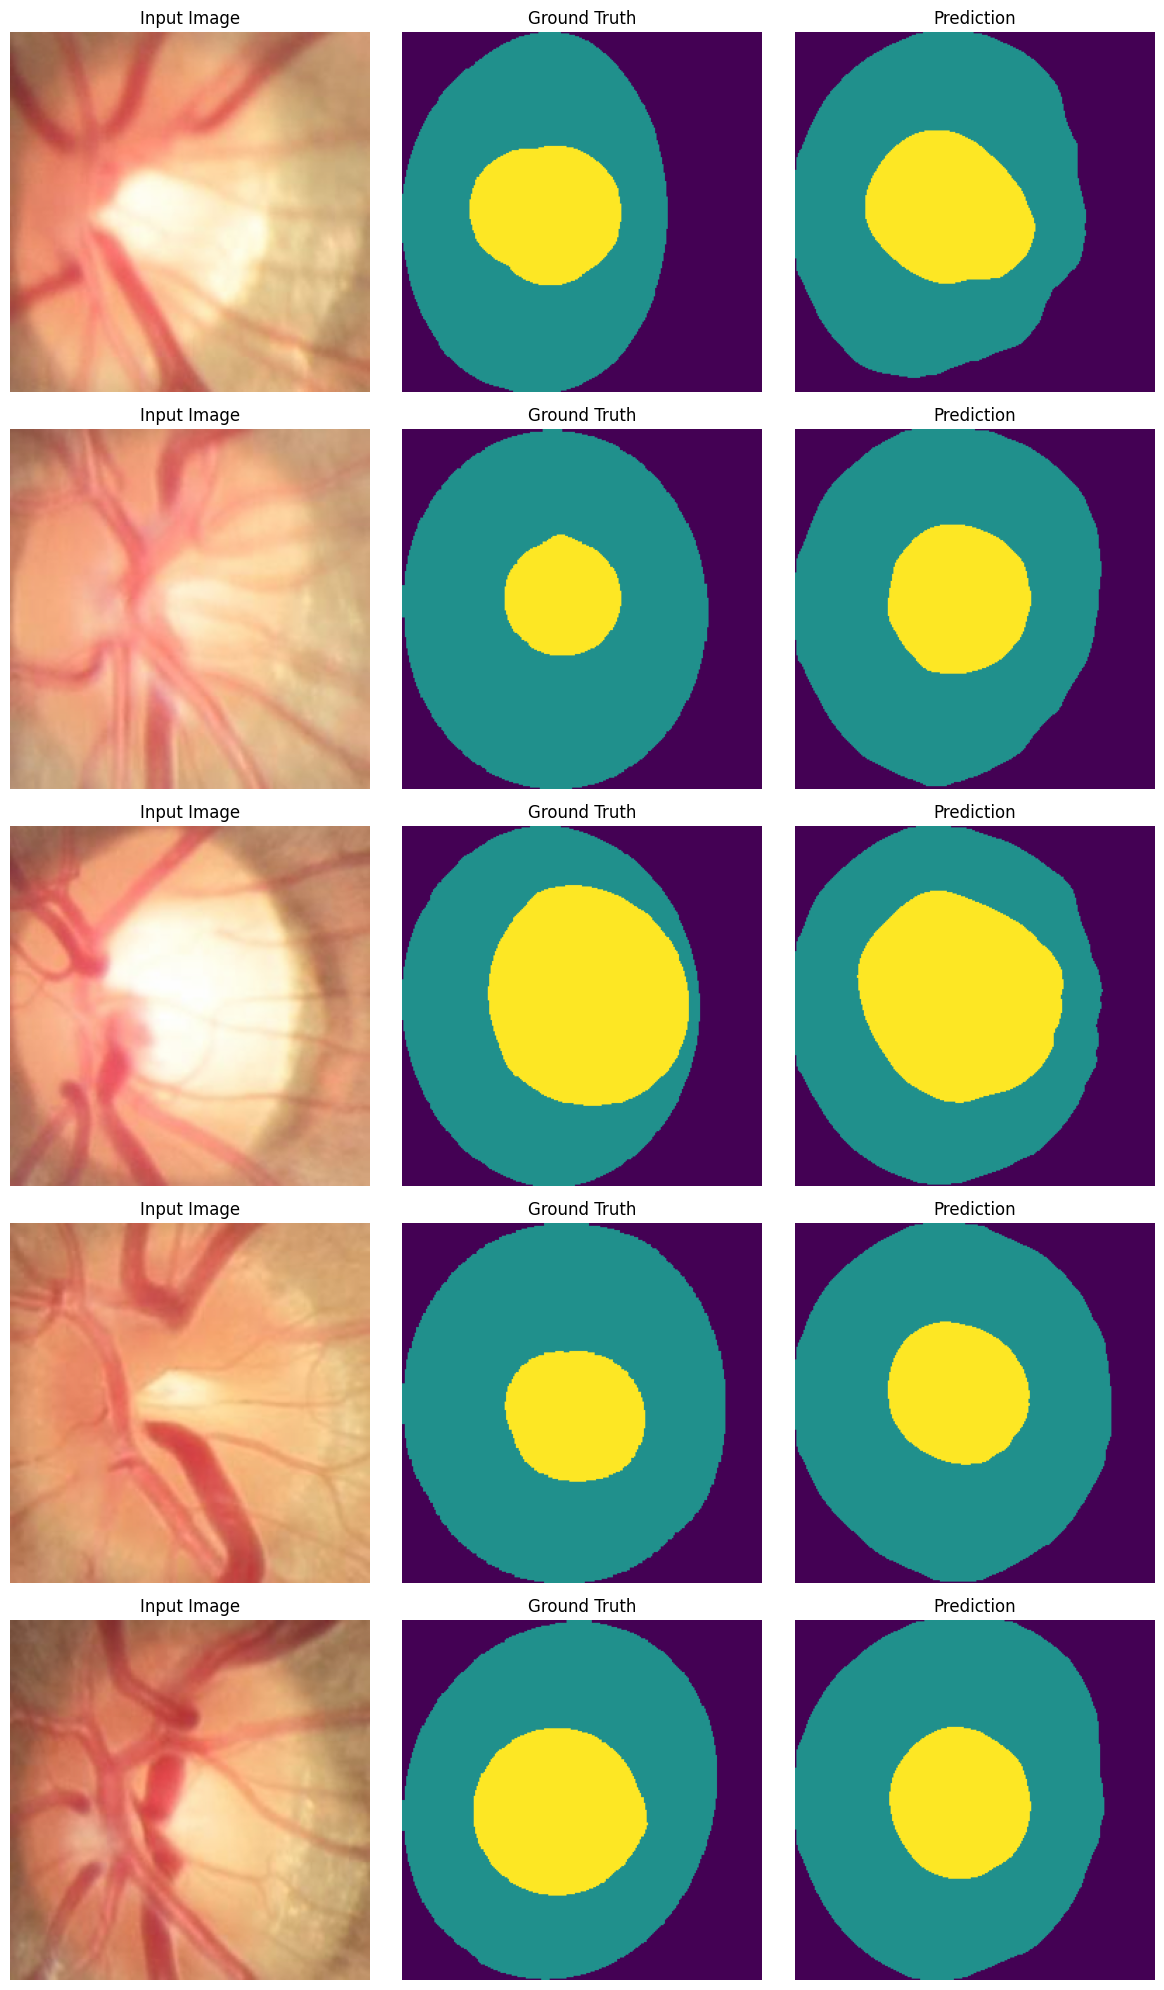

In [22]:
# Cell 17: Visualize predictions vs ground truth
@torch.no_grad()
def visualize_predictions(model, dataset, device, num_samples=5):
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    indices = random.sample(range(len(dataset)), num_samples)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)
        pred = model(input_tensor)
        pred_mask = torch.argmax(pred, dim=1).squeeze(0).cpu().numpy()

        img_np = image.permute(1, 2, 0).cpu().numpy()
        img_np = (img_np * std + mean).clip(0, 1)  # unnormalize for display

        axes[i, 0].imshow(img_np); axes[i, 0].set_title("Input Image"); axes[i, 0].axis('off')
        axes[i, 1].imshow(mask.cpu().numpy(), cmap='viridis', vmin=0, vmax=2); axes[i, 1].set_title("Ground Truth"); axes[i, 1].axis('off')
        axes[i, 2].imshow(pred_mask, cmap='viridis', vmin=0, vmax=2); axes[i, 2].set_title("Prediction"); axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig('/content/predictions_sample.png', dpi=100)
    plt.show()

visualize_predictions(best_model, test_ds, DEVICE, num_samples=5)

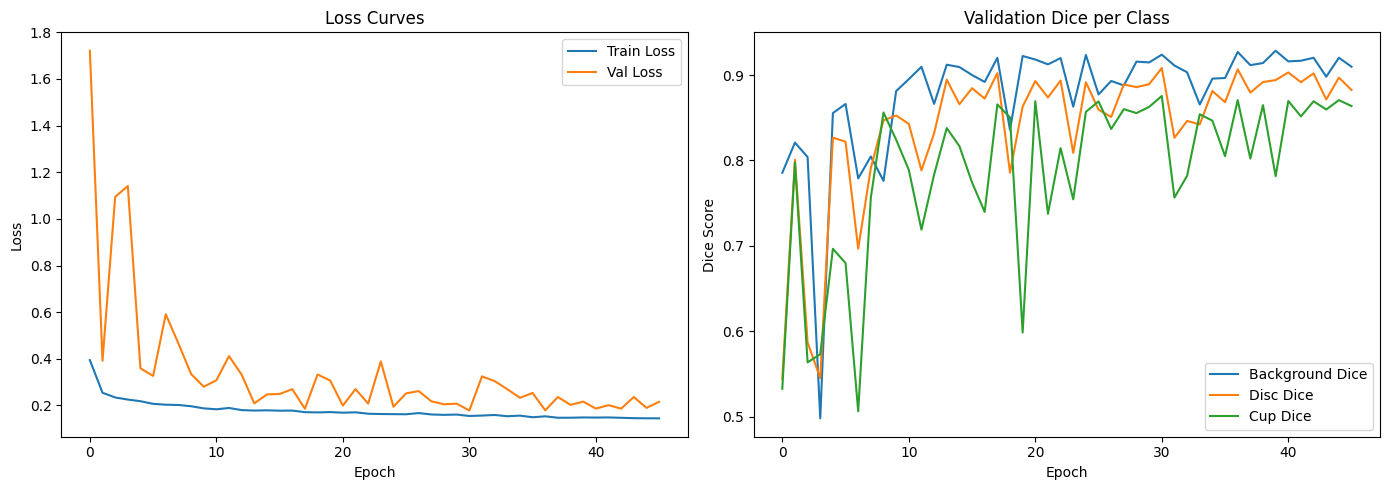

In [23]:
# Cell 18: Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title("Loss Curves")

axes[1].plot(history["val_dice_bg"], label="Background Dice")
axes[1].plot(history["val_dice_disc"], label="Disc Dice")
axes[1].plot(history["val_dice_cup"], label="Cup Dice")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dice Score"); axes[1].legend(); axes[1].set_title("Validation Dice per Class")

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=100)
plt.show()